# Week10 GCN Experiment

本 Notebook 对应第十周任务：

1. 复用第九周的图结构；
2. 构造简单的多站点图时序样本；
3. 使用 `GCNConv` 搭建一个基础 GCN 回归模型；
4. 在测试集上计算 MAE / RMSE，并说明 GCN 的消息传递机制。

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

_cwd = os.getcwd()
_root = os.path.dirname(_cwd) if os.path.basename(_cwd) == 'week10' else _cwd
sys.path.insert(0, os.path.join(_root, 'week10'))

from data import prepare_gcn_data
from models import GCNRegressor
from train import GraphSequenceDataset, train_gcn

import torch
from torch.utils.data import DataLoader

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['axes.unicode_minus'] = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Torch version: {torch.__version__}')
print(f'Device: {device}')

Torch version: 2.6.0+cu124
Device: cuda


## 1. 构造 GCN 数据

这里把过去 `seq_len` 个时间步的多站点特征拼成每个节点的输入向量，并预测下一时刻所有站点的功率。

In [2]:
SEQ_LEN = 4
PRED_HORIZON = 1
DIST_THRESHOLD_KM = 150.0
BATCH_SIZE = 16
EPOCHS = 8
LR = 1e-3

prepared = prepare_gcn_data(
    distance_threshold_km=DIST_THRESHOLD_KM,
    seq_len=SEQ_LEN,
    pred_horizon=PRED_HORIZON,
)

print(f'Train X shape: {prepared.train_x.shape}')
print(f'Train y shape: {prepared.train_y.shape}')
print(f'Test X shape: {prepared.test_x.shape}')
print(f'Test y shape: {prepared.test_y.shape}')
print(f'Edge index shape: {prepared.edge_index.shape}')
print(f'Station count: {len(prepared.station_ids)}')
print(f'Input feature dim per node: {prepared.train_x.shape[-1]}')

Train X shape: (6524, 10, 24)
Train y shape: (6524, 10)
Test X shape: (1632, 10, 24)
Test y shape: (1632, 10)
Edge index shape: (2, 44)
Station count: 10
Input feature dim per node: 24


In [3]:
train_ds = GraphSequenceDataset(prepared.train_x, prepared.train_y)
test_ds = GraphSequenceDataset(prepared.test_x, prepared.test_y)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

edge_index = torch.from_numpy(prepared.edge_index).long().to(device)
print(f'Train samples: {len(train_ds)}')
print(f'Test samples: {len(test_ds)}')

Train samples: 6524
Test samples: 1632


## 2. 搭建简单 GCN 模型

模型结构：

- `GCNConv` 提取邻居聚合后的空间特征；
- 两层图卷积后接线性层；
- 每个节点输出一个标量，表示下一时刻功率预测值。

In [4]:
model = GCNRegressor(
    input_dim=prepared.train_x.shape[-1],
    hidden_dim=32,
    output_dim=1,
    dropout=0.1,
).to(device)
model

GCNRegressor(
  (conv1): GCNConv(24, 32)
  (conv2): GCNConv(32, 32)
  (dropout): Dropout(p=0.1, inplace=False)
  (head): Linear(in_features=32, out_features=1, bias=True)
)

## 3. 训练 GCN

这里训练一个最小可运行的多站点 GCN 一步预测模型。

In [5]:
model, history = train_gcn(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    edge_index=edge_index,
    epochs=EPOCHS,
    lr=LR,
    device=device,
)

Epoch 01/8 | train_loss=44.32875 | test_loss=14.15400 | test_mae=2.00550 | test_rmse=3.76218
Epoch 02/8 | train_loss=14.99512 | test_loss=14.55755 | test_mae=1.93250 | test_rmse=3.81544
Epoch 03/8 | train_loss=13.98023 | test_loss=12.89197 | test_mae=1.83499 | test_rmse=3.59054
Epoch 04/8 | train_loss=12.92008 | test_loss=13.55964 | test_mae=1.87024 | test_rmse=3.68234
Epoch 05/8 | train_loss=12.48380 | test_loss=12.33667 | test_mae=1.75864 | test_rmse=3.51236
Epoch 06/8 | train_loss=12.20740 | test_loss=13.04473 | test_mae=1.82252 | test_rmse=3.61175
Epoch 07/8 | train_loss=12.13690 | test_loss=11.89258 | test_mae=1.71635 | test_rmse=3.44856
Epoch 08/8 | train_loss=11.89917 | test_loss=11.32489 | test_mae=1.69646 | test_rmse=3.36525


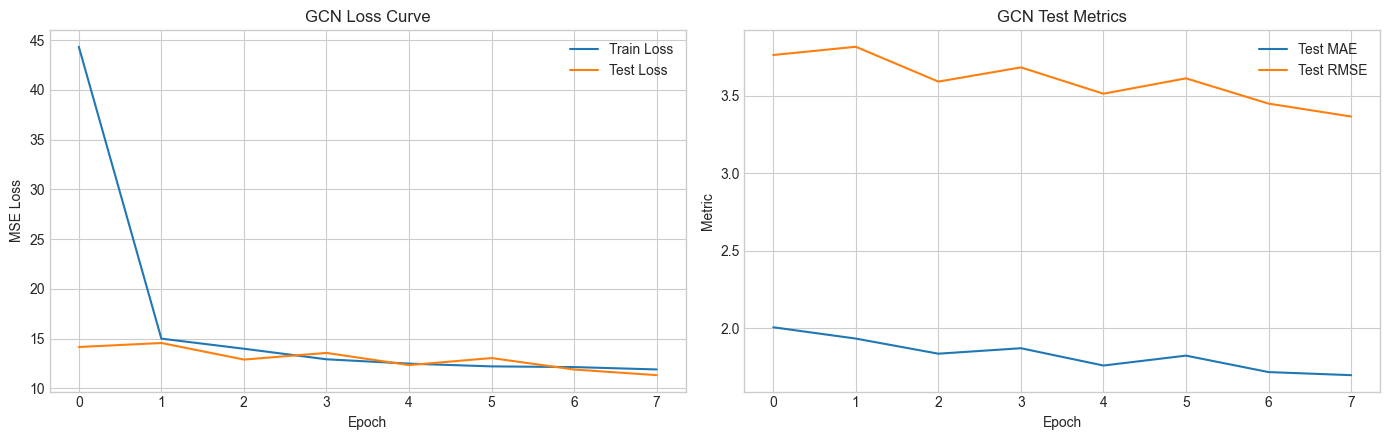

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['test_loss'], label='Test Loss')
axes[0].set_title('GCN Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()

axes[1].plot(history['test_mae'], label='Test MAE')
axes[1].plot(history['test_rmse'], label='Test RMSE')
axes[1].set_title('GCN Test Metrics')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Metric')
axes[1].legend()
plt.tight_layout()
plt.show()

## 4. 第十周检查点说明

GCN 的消息传递机制可以这样理解：

1. 每个站点先有自己的节点特征；
2. `GCNConv` 会把邻居节点的信息按照图结构聚合过来；
3. 经过聚合后，一个节点的表示不仅包含自身历史，还包含空间邻居的信息；
4. 因此，GCN 适合处理多站点之间存在空间相关性的预测任务。